In [1]:
import gymnasium as gym
import numpy as np

env = gym.make("MountainCar-v0")

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

state, _ = env.reset()
print("Initial state:", state)

for _ in range(5):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, _ = env.step(action)
    
    print("Next state:", next_state, "Reward:", reward)
    
    if terminated or truncated:
        break

Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Initial state: [-0.5662434  0.       ]
Next state: [-0.5649244   0.00131896] Reward: -1.0
Next state: [-0.56229633  0.00262811] Reward: -1.0
Next state: [-0.55837864  0.00391769] Reward: -1.0
Next state: [-0.55320054  0.00517807] Reward: -1.0
Next state: [-0.54880077  0.00439979] Reward: -1.0


HERE, WE CAN SEE THE CONTINUOUS STATES IN FLOAT, WHICH MEANS INFINITE STATES.

In [6]:
class TileCoder:
    def __init__(self, low, high, num_tilings=8, tiles=(8, 8)):
        self.low = np.array(low)
        self.high = np.array(high)
        self.num_tilings = num_tilings
        self.tiles = np.array(tiles)

        # self.tile_width = (self.high - self.low) / self.tiles   # ⚠️ BUG HERE
        self.tile_width = (self.high - self.low) / (self.tiles - 1)

        self.offsets = [
            (i / num_tilings) * self.tile_width
            for i in range(num_tilings)
        ]

        self.total_tiles = num_tilings * np.prod(self.tiles)

    def get_features(self, state):
        features = np.zeros(self.total_tiles)

        for i, offset in enumerate(self.offsets):
            shifted = (state - self.low + offset) / self.tile_width
            indices = np.floor(shifted).astype(int)

            indices = np.clip(indices, 0, self.tiles - 1)

            tile_index = (
                i * np.prod(self.tiles)
                + indices[0] * self.tiles[1]
                + indices[1]
            )

            features[tile_index] = 1

        return features

In [7]:
tile_coder = TileCoder(
    low=env.observation_space.low,
    high=env.observation_space.high,
    num_tilings=8,
    tiles=(8, 8)
)

state = np.array([-0.5, 0.02])
features = tile_coder.get_features(state)

print("Feature vector size:", len(features))
print("Number of active features:", np.sum(features))
print("Active indices:", np.where(features == 1)[0][:10])

Feature vector size: 512
Number of active features: 8.0
Active indices: [ 20  84 148 220 284 349 413 477]


In [8]:
for s in [
    [-0.5, 0.02],
    [-0.51, 0.02],
    [-0.7, -0.01]
]:
    f = tile_coder.get_features(np.array(s))
    print(s, "→ active:", np.where(f == 1)[0])

[-0.5, 0.02] → active: [ 20  84 148 220 284 349 413 477]
[-0.51, 0.02] → active: [ 20  84 148 220 284 349 413 477]
[-0.7, -0.01] → active: [ 11  83 147 211 275 339 403 467]


In [9]:
print("Tile width:", tile_coder.tile_width)

print("Expected width:",
      (env.observation_space.high - env.observation_space.low) / (np.array([8,8]) - 1))

Tile width: [0.25714287 0.02      ]
Expected width: [0.25714287 0.02      ]


In [13]:
class SARSAAgent:
    def __init__(self, n_actions, feature_size, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        
        self.weights = np.zeros((n_actions, feature_size))

    def get_q(self, features, action):
        return np.dot(self.weights[action], features)

    def get_all_q(self, features):
        return np.array([self.get_q(features, a) for a in range(self.n_actions)])

    def select_action(self, features):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return np.argmax(self.get_all_q(features))

    def update(self, features, action, reward, next_features, next_action):
        q_current = self.get_q(features, action)
        q_next = self.get_q(next_features, next_action)

        target = reward + self.gamma * q_next
        delta = target - q_current

        # BUG- HERE
        self.weights[action] += self.alpha * delta * features

In [18]:
agent = SARSAAgent(
    n_actions=env.action_space.n,
    feature_size=tile_coder.total_tiles,
    alpha = 0.1 / 8,
    epsilon=0.1
)

episodes = 500
steps_per_episode = []

for ep in range(episodes):
    state, _ = env.reset()
    features = tile_coder.get_features(state)
    action = agent.select_action(features)

    steps = 0

    while True:
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        next_features = tile_coder.get_features(next_state)
        next_action = agent.select_action(next_features)

        agent.update(features, action, reward, next_features, next_action)

        features = next_features
        action = next_action

        steps += 1

        if done:
            break

    steps_per_episode.append(steps)

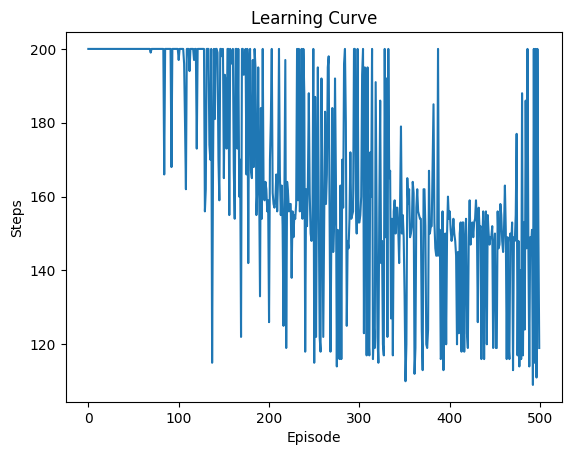

In [20]:
import matplotlib.pyplot as plt

plt.plot(steps_per_episode)
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("Learning Curve")
plt.show()

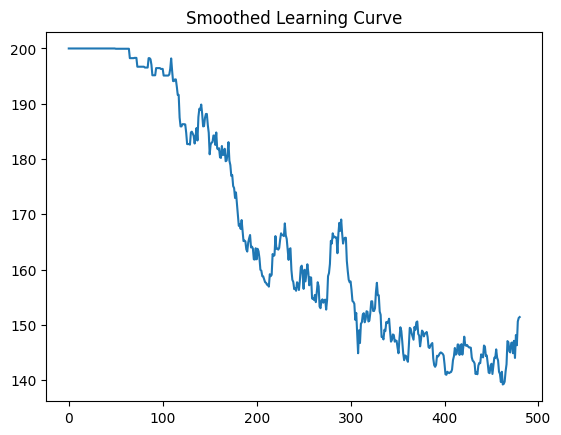

In [21]:
window = 20
smoothed = np.convolve(steps_per_episode, np.ones(window)/window, mode='valid')

plt.plot(smoothed)
plt.title("Smoothed Learning Curve")
plt.show()

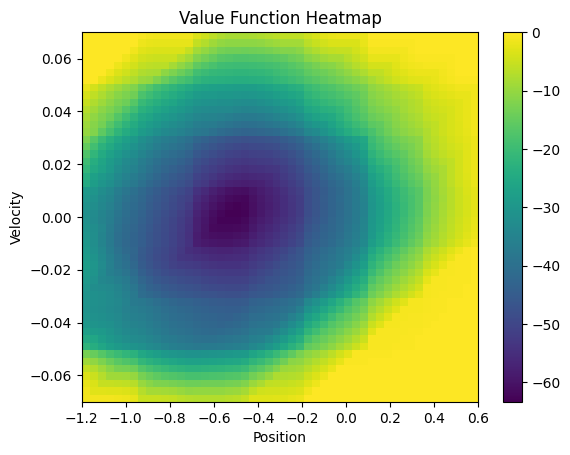

In [22]:
pos = np.linspace(-1.2, 0.6, 50)
vel = np.linspace(-0.07, 0.07, 50)

Z = np.zeros((50, 50))

for i, p in enumerate(pos):
    for j, v in enumerate(vel):
        state = np.array([p, v])
        features = tile_coder.get_features(state)
        Z[j, i] = np.max(agent.get_all_q(features))

plt.imshow(Z, extent=[-1.2, 0.6, -0.07, 0.07], origin='lower', aspect='auto')
plt.colorbar()
plt.title("Value Function Heatmap")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.show()

# POLICY VISUALIZATION

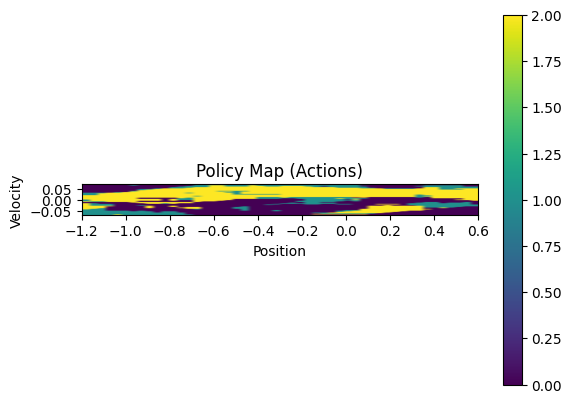

In [23]:
policy = np.zeros((50, 50))

for i, p in enumerate(pos):
    for j, v in enumerate(vel):
        state = np.array([p, v])
        features = tile_coder.get_features(state)
        policy[j, i] = np.argmax(agent.get_all_q(features))

plt.imshow(policy, extent=[-1.2, 0.6, -0.07, 0.07], origin='lower')
plt.colorbar()
plt.title("Policy Map (Actions)")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.show()

In [24]:
print(min(vel), max(vel))

-0.07 0.07


In [25]:
vel = np.linspace(-0.07, 0.07, 50)